In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

df = pd.read_csv(os.path.join('..', 'data.csv'), index_col=0)
df

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,,
0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1


## Dataset Overview

The dataset includes 15 features and one binary target variable (TenYearCHD). 
Features:
- Demographic:
    - age (continuous): Age of the Patient
    - education (ordinal): 1: Higher Secondary, 2: Graduate, 3: Post-graduate, 4: PhD
    - sex (nominal): 'M', 'F'
- Behavioral History:
    - is_smoking (nominal): whether or not the patient is a current smoker ('YES', 'NO')
    - cigsPerDay (continuous): number of cigarettes per day
- Past Medical History:
    - BPMeds (nominal): whether or not the patient is on blood pressure medications (0, 1)
    - prevalentStroke (nominal): whether or not the patient has had a stroke (0, 1)
    - prevalentHyp (nominal): whether or not the patient has Hypertension (0, 1)
    - diabetes (nominal): whether or not the patient has Diabetes (0, 1)
- Current Medical Data (Physical Examination, Lab Tests):
    - totChol (continuous): total cholesterol level
    - sysBP (continuous): systolic blood pressure
    - diaBP (continuous): diastolic blood pressure
    - BMI (continuous): Body Mass Index
    - heartRate (continuous)
    - glucose (continuous)

- Target variable: TenYearCHD: 10-Y outcome (1 for those who have developed CHD, 0 for those who haven't)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3390 entries, 0 to 3389
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              3390 non-null   int64  
 1   education        3303 non-null   float64
 2   sex              3390 non-null   object 
 3   is_smoking       3390 non-null   object 
 4   cigsPerDay       3368 non-null   float64
 5   BPMeds           3346 non-null   float64
 6   prevalentStroke  3390 non-null   int64  
 7   prevalentHyp     3390 non-null   int64  
 8   diabetes         3390 non-null   int64  
 9   totChol          3352 non-null   float64
 10  sysBP            3390 non-null   float64
 11  diaBP            3390 non-null   float64
 12  BMI              3376 non-null   float64
 13  heartRate        3389 non-null   float64
 14  glucose          3086 non-null   float64
 15  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(5), object(2)
memory usage: 450.2+ KB


As we can see there is a varying degree of missingness per features in the dataset.

### Initial Data Inspection & Cleaning

<Axes: title={'center': 'Missing Values Per Column'}>

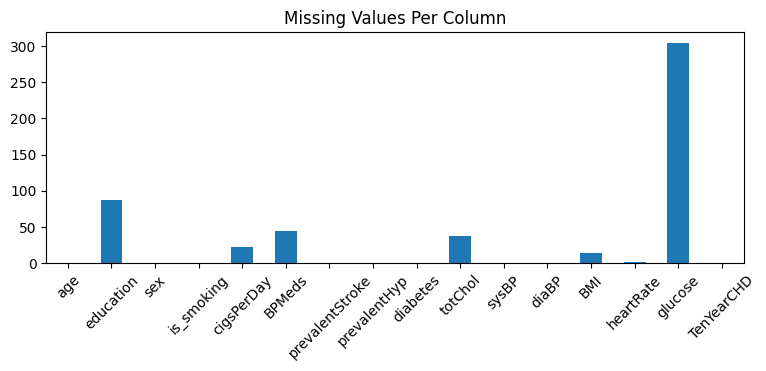

In [5]:
df.isna().sum().plot(kind='bar', figsize=(9, 3), title="Missing Values Per Column", rot=45)

In [6]:
df.shape[0], df.dropna().shape[0]

(3390, 2927)

The number of missing values is highest for `glucose` which has about 300/3390 missing cells (roughly 9%), followed by `education` which is missing roughly 100 datapoints.\
The simplest approach to address this problem would be dropping rows with any missing values (i.e. Complete Case Analysis), which we adopt, but we can later revisit this decision if needed, and perhaps utilize other methods; if it is later revealed that `glucose` has negligible predictive utility we can then discard the column instead of the rows.

In [7]:
# number of patients if we drop null values after we remove `glucose` column
df[[c for c in df.columns if c != 'glucose']].dropna().shape[0]

3189

In [8]:
df.dropna(inplace=True)

In [9]:
df.columns.to_list()

['age',
 'education',
 'sex',
 'is_smoking',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [10]:
# sanity check for numerical data
columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
df[columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2927.0,49.507345,8.597191,32.00,42.00,49.00,56.00,70.0
cigsPerDay,2927.0,9.112743,11.882784,0.00,0.00,0.00,20.00,70.0
totChol,2927.0,237.129142,44.613282,113.00,206.00,234.00,264.00,600.0
sysBP,2927.0,132.626409,22.326197,83.50,117.00,128.50,144.00,295.0
diaBP,2927.0,82.906218,12.078873,48.00,74.50,82.00,90.00,142.5
BMI,2927.0,25.797041,4.130376,15.96,23.03,25.38,28.04,56.8
heartRate,2927.0,75.888282,11.971207,45.00,68.00,75.00,83.00,143.0
glucose,2927.0,81.934404,24.106943,40.00,71.00,78.00,87.00,394.0


In [11]:
# sanity check for categorical data
for col in [
    'education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp',
    'diabetes', 'TenYearCHD'
]:
    print(f"{col}: {df[col].unique().tolist()}")

education: [4.0, 1.0, 3.0, 2.0]
sex: ['M', 'F']
is_smoking: ['NO', 'YES']
BPMeds: [0.0, 1.0]
prevalentStroke: [0, 1]
prevalentHyp: [1, 0]
diabetes: [0, 1]
TenYearCHD: [0, 1]


There are no unexpected/sentinel values as we can see.

### Target Variable Class Imbalance

CHD-: 2483  |  CHD+: 444 | Ratio (CHD- / CHD+): 5.59


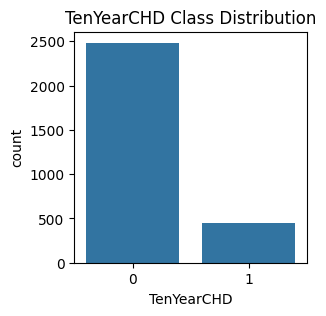

In [12]:
plt.figure(figsize=(3, 3))
sns.countplot(x='TenYearCHD', data=df)
plt.title('TenYearCHD Class Distribution')

num = df['TenYearCHD'].value_counts()
print(f"CHD-: {num[0]}  |  CHD+: {num[1]} | Ratio (CHD- / CHD+): {num[0]/num[1]:.2f}")

There are roughly 5.6 patients without the disease for every one patient who develops it. This is a meaningful class imbalance that we will need to address before model training.

### Distribution of Predictor Variables

In [13]:
categorical_features = [
    'education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes'
]
numeric_features = [
    'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

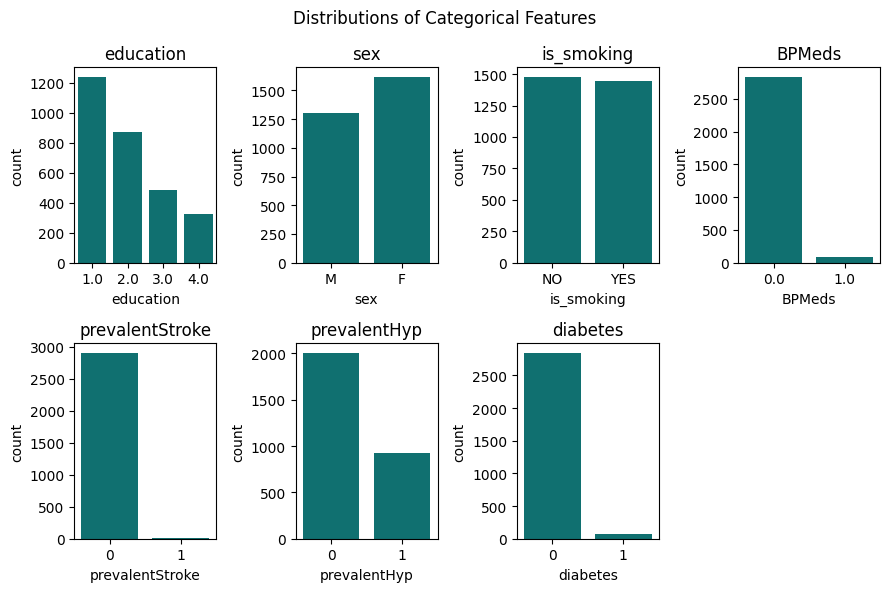

In [14]:
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(9, 6))

axes = axes.flatten()
for col, ax in zip(categorical_features, axes):
    # ax.pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%.1f')
    sns.countplot(data=df, x=col, ax=ax, color='teal')
    ax.set_title(col)

for i in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Distributions of Categorical Features")
plt.tight_layout()

As we can see `sex` and `is_smoking` variables are balanced, whereas other variables demonstrate varying degrees of imbalance, notably `prevalentStroke` is only present in a very small portion of the patients (which is expected in a clinical dataset).

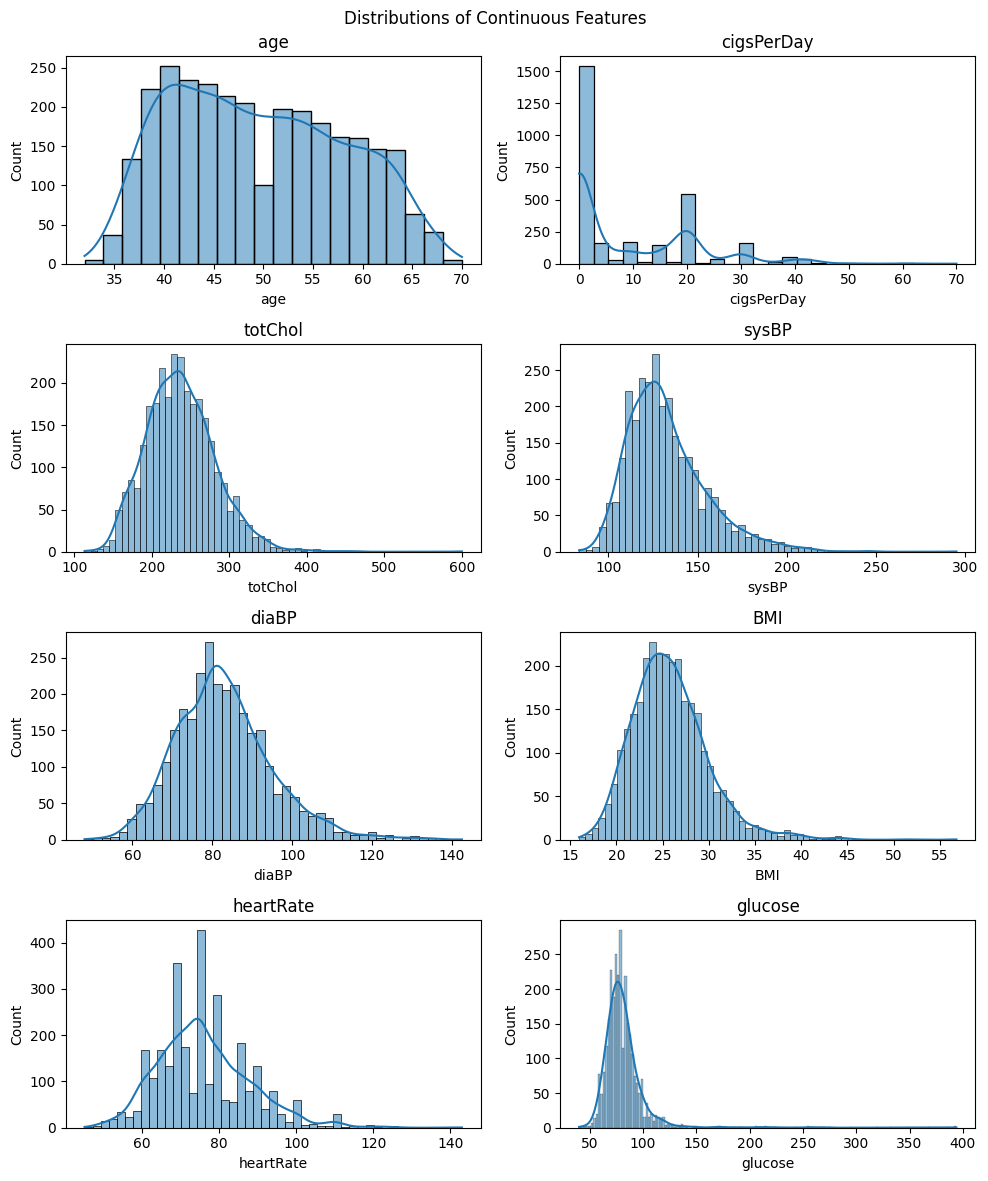

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
idx_row, idx_col = 0, 0

for col in numeric_features:
    sns.histplot(df[col], kde=True, ax=axes[idx_row][idx_col])
    axes[idx_row][idx_col].set_title(col)
    idx_col += 1
    if idx_col == 2:
        idx_col = 0
        idx_row += 1

plt.suptitle("Distributions of Continuous Features")
plt.tight_layout()
plt.show()

A few things stand out. `cigsPerDay` is very right-skewed (i.e. many people smoke 0 cigarettes) which creates a large spike at zero. `glucose` also has a long right tail. The blood pressure, cholesterol, and heartRate variables look roughly normal and symmetric but with some high-end outliers.

### Bivariate Distributions

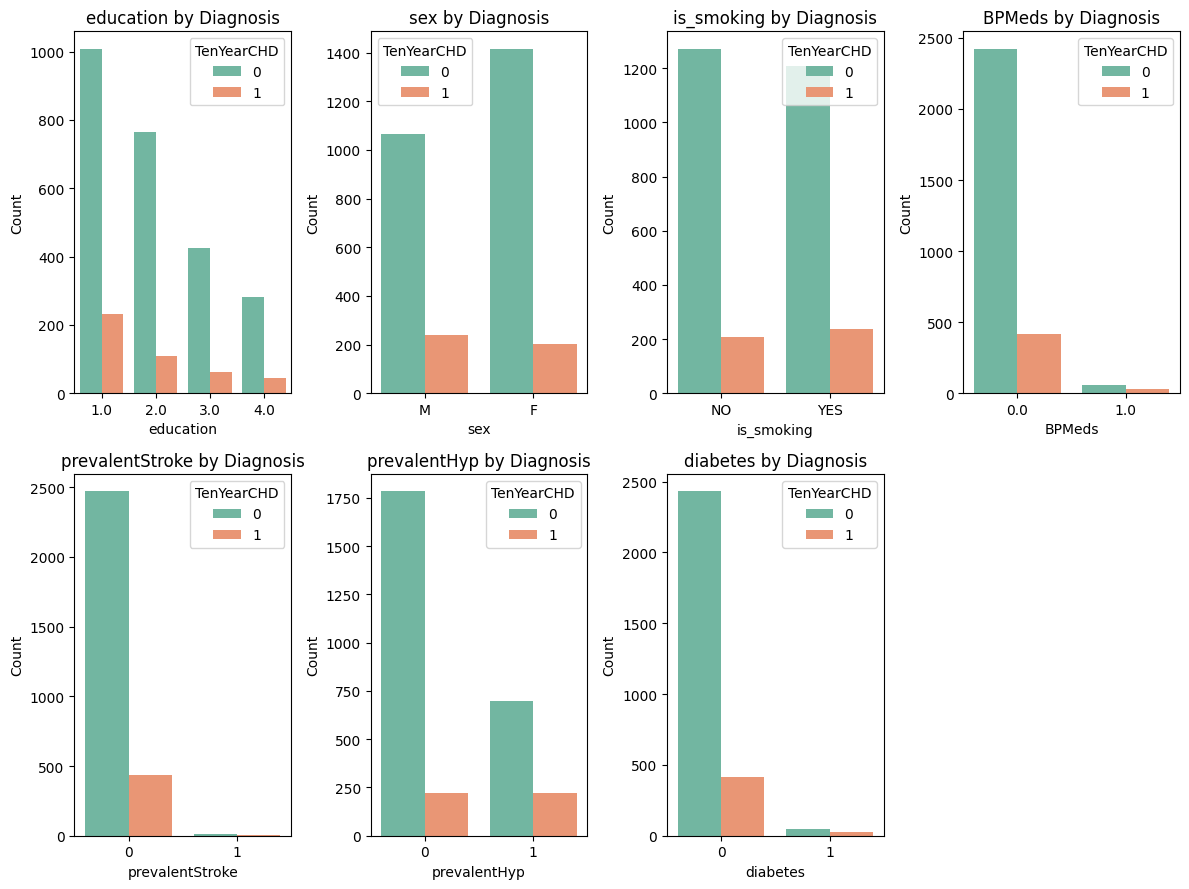

In [16]:
ncols = 4
nrows = 2
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, hue='TenYearCHD', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Diagnosis', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

`sns.countplot` with `hue='TenYearCHD'` is a simple and effective approach to visualize the distribution of CHD+ and CHD- cases among different groups of each categorical variable, but we can use a better visualization approach to see the differences among groups better.

In [17]:
sex_data = df[['sex', 'TenYearCHD']]
sex_data

,sex,TenYearCHD
id,,
1,M,0
2,F,0
3,M,1
4,F,0
5,F,1
...,...,...
3384,F,0
3385,F,0
3386,F,0


In [18]:
sex_crosstab = sex_data.groupby(['sex', 'TenYearCHD']).size().unstack('TenYearCHD')
sex_crosstab

TenYearCHD,0,1
sex,,
F,1417,203
M,1066,241


In [19]:
pct = (sex_crosstab.T / sex_crosstab.sum(axis=1)).T
pct

TenYearCHD,0,1
sex,,
F,0.874691,0.125309
M,0.815608,0.184392


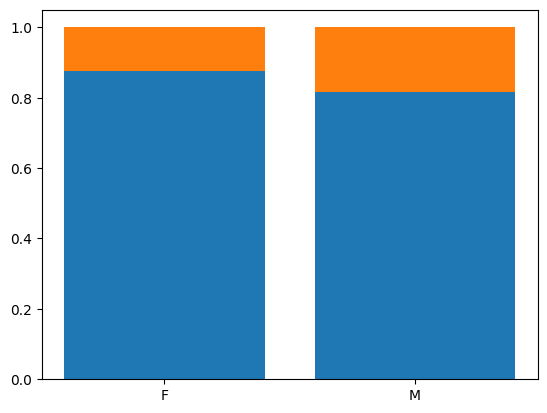

In [20]:
plt.bar(x=[0, 1], height=pct[pct.columns[0]], bottom=[0, 0])
plt.bar(x=[0, 1], height=pct[pct.columns[1]], bottom=pct[pct.columns[0]])
plt.xticks([0, 1], pct.index)
plt.show()

In [21]:
def plot_stacked_barchart(data, title=None):
    pct = ((data.T / data.sum(axis=1)) * 100).T
    r = list(range(len(data)))
    bottom = [0] * len(data)
    
    for i, col in enumerate(pct.columns):
        bars = plt.bar(
            r, pct[col], bottom=bottom, color=('teal' if i==0 else 'crimson'),
            edgecolor='white', label=col
        )
        # annotate bars with actual counts and percentages
        for bar, raw in zip(bars, data[col]):
            height = bar.get_height()
            plt.text(
                x = bar.get_x() + bar.get_width() / 2,
                y = bar.get_y() + height / 2,
                s = f'{raw} ({round(height, 1)}%)',
                ha='center', va='center',
                color='black', fontsize=7
            )
        bottom = [b + p for b, p in zip(bottom, pct[col])]
    
    plt.title(title)
    plt.xticks(r, data.index)
    plt.ylabel('Portion %')
    plt.legend(loc='lower right', fontsize=8)

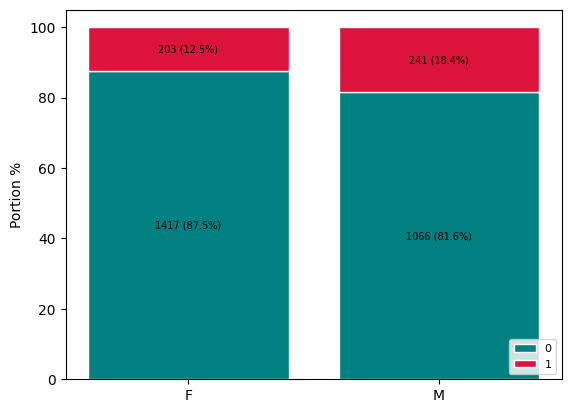

In [22]:
plot_stacked_barchart(sex_crosstab)

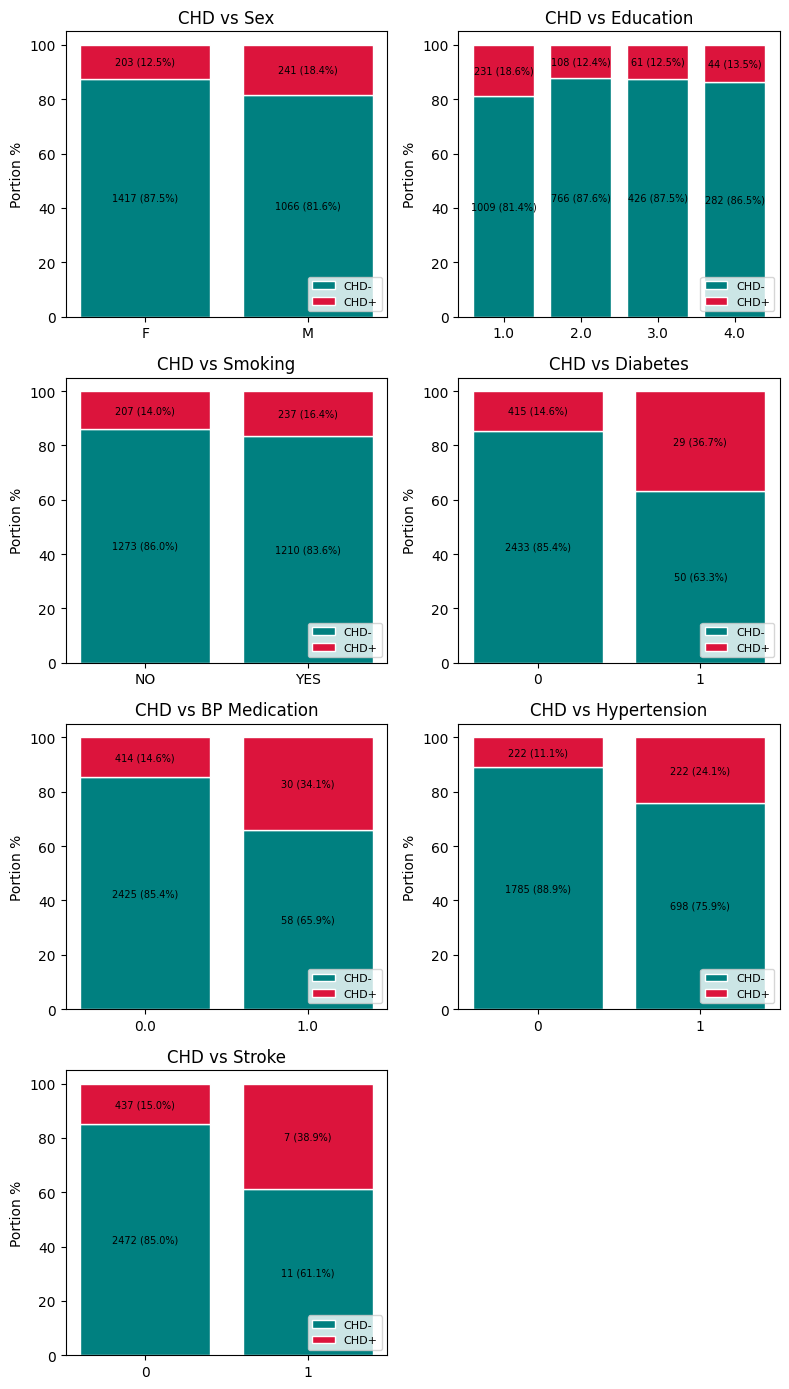

In [23]:
fig = plt.figure(figsize=(8, 14))

cat_comparisons = [
    ('sex', 'CHD vs Sex'),
    ('education', 'CHD vs Education'),
    ('is_smoking', 'CHD vs Smoking'),
    ('diabetes', 'CHD vs Diabetes'),
    ('BPMeds', 'CHD vs BP Medication'),
    ('prevalentHyp', 'CHD vs Hypertension'),
    ('prevalentStroke', 'CHD vs Stroke'),
]

for i, (feat, title) in enumerate(cat_comparisons, 1):
    plt.subplot(4, 2, i)
    temp_data = df[[feat, 'TenYearCHD']].groupby([feat, 'TenYearCHD']).size().unstack('TenYearCHD')
    temp_data.columns = ['CHD-', 'CHD+']
    plot_stacked_barchart(temp_data, title=title)

plt.tight_layout()
plt.show()

Stroke history, hypertension as well as diabetes all show clearly distinct proportions of CHD+/CHD- groups. Sex, education and smoking also demonstrate some minor differences among the groups, with males, and secondary education groups having a higher CHD+ portionality than other groups...

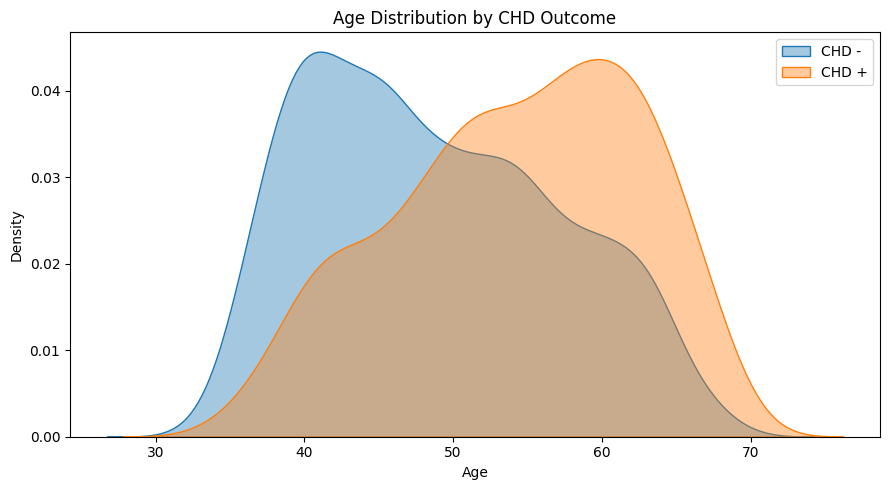

In [24]:
plt.figure(figsize=(9, 5))
sns.kdeplot(df[df['TenYearCHD'] == 0]['age'], label='CHD -', fill=True, alpha=0.4)
sns.kdeplot(df[df['TenYearCHD'] == 1]['age'], label='CHD +', fill=True, alpha=0.4)
plt.title('Age Distribution by CHD Outcome')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

Patients who develop CHD skew older, which is expected.

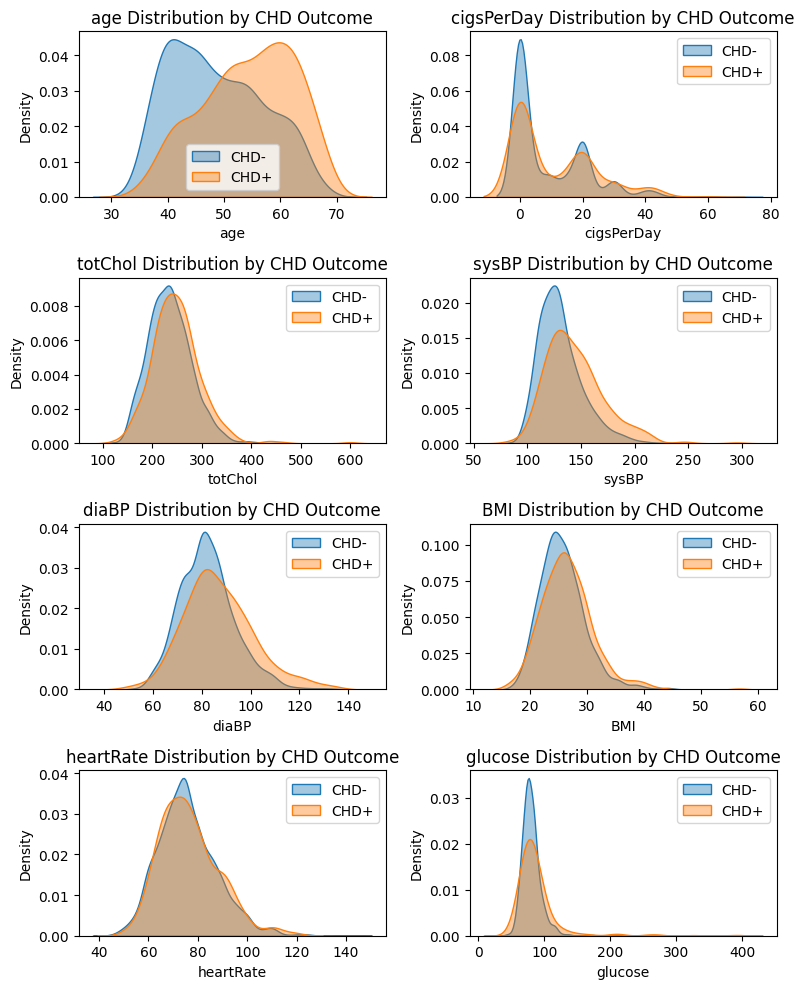

In [25]:
fig = plt.figure(figsize=(8, 10))
for i, feat in enumerate(numeric_features, 1):
    plt.subplot(4, 2, i)
    sns.kdeplot(df[df['TenYearCHD'] == 0][feat], label='CHD-', fill=True, alpha=0.4)
    sns.kdeplot(df[df['TenYearCHD'] == 1][feat], label='CHD+', fill=True, alpha=0.4)
    plt.title(f'{feat} Distribution by CHD Outcome')
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
plt.show()

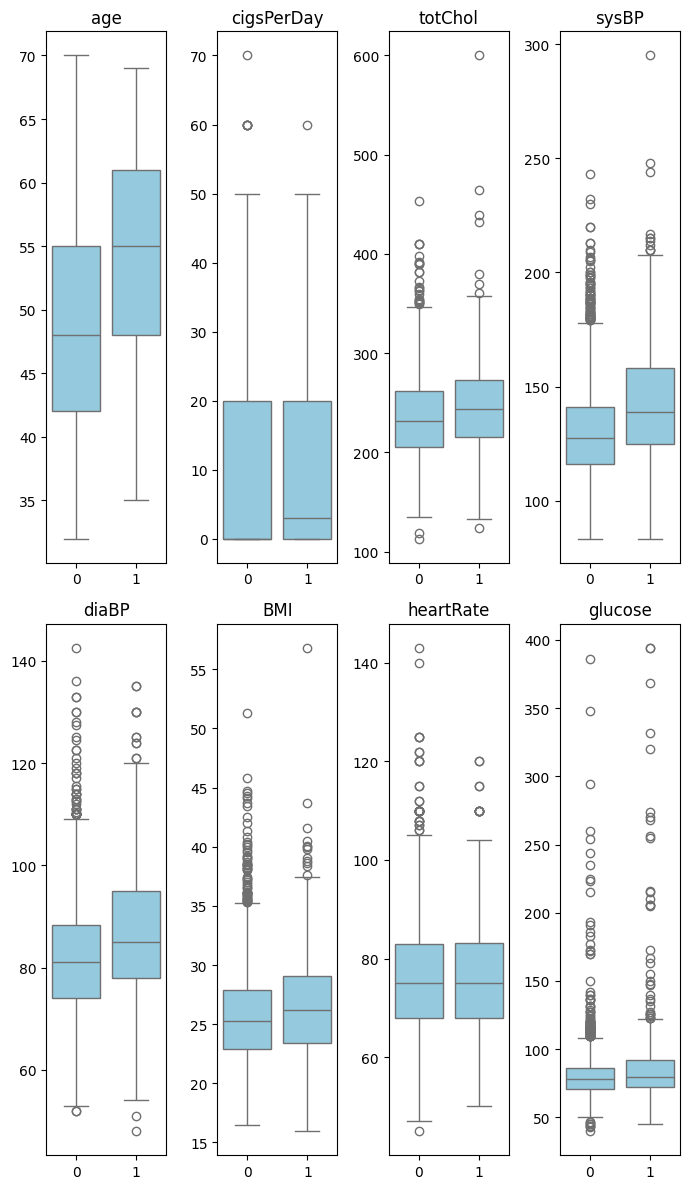

In [26]:
# boxplots of continuous features vs CHD outcome
fig, axes = plt.subplots(2, 4, figsize=(7, 12))
for feat, ax in zip(numeric_features, axes.flatten()):
    sns.boxplot(x=df['TenYearCHD'], y=df[feat], ax=ax, color='skyblue')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

Almost all of the features depict a separation between CHD+ and CHD- groups, but to a varying extent.

### Correlation Analysis

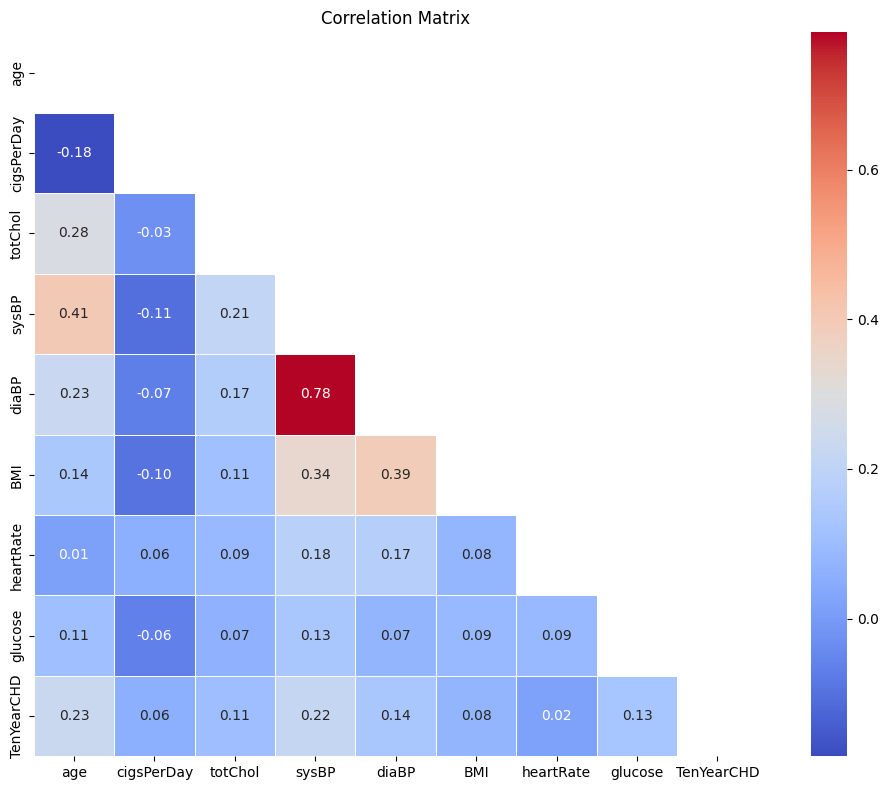

In [27]:
corr = df[numeric_features + ['TenYearCHD']].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr))
sns.heatmap(
    corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm', linewidths=0.5, square=True
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

`sysBP` and `diaBP` are fairly correlated with each other as expected, since both measure blood pressure. `age` shows the strongest positive correlation with TenYearCHD among the continuous features, followed by `sysBP`, 'diaBP` and `glucose`. No pair of predictor variables is correlated strongly enough to raise immediate multicollinearity concerns.

### Descriptive Statistics

In [28]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2927.0,49.507345,8.597191,32.00,42.00,49.00,56.00,70.0
cigsPerDay,2927.0,9.112743,11.882784,0.00,0.00,0.00,20.00,70.0
totChol,2927.0,237.129142,44.613282,113.00,206.00,234.00,264.00,600.0
sysBP,2927.0,132.626409,22.326197,83.50,117.00,128.50,144.00,295.0
diaBP,2927.0,82.906218,12.078873,48.00,74.50,82.00,90.00,142.5
BMI,2927.0,25.797041,4.130376,15.96,23.03,25.38,28.04,56.8
heartRate,2927.0,75.888282,11.971207,45.00,68.00,75.00,83.00,143.0
glucose,2927.0,81.934404,24.106943,40.00,71.00,78.00,87.00,394.0


A few things worth noting from the summary stats. The average age is around 49 years and the range goes from 32 to 70. The max cigarettes per day is 70 which is quite extreme. Average BMI sits at about 25.8, right at the border between normal and overweight. Glucose looks fairly healthy on average but the max value of 394 suggests some severe outliers in that column. Also sysBP and diaBP columns show some outliers...

### Hypothesis Testing

In [29]:
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

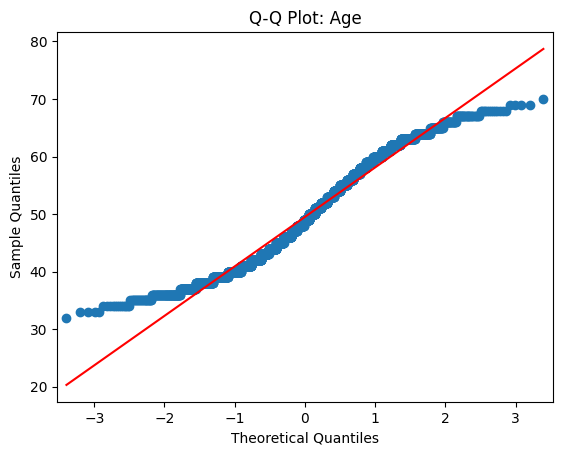

In [30]:
# Q-Q plot to visually assess normality
qqplot(df['age'], line='s')
plt.title('Q-Q Plot: Age')
plt.show()

In [31]:
stat, p = stats.shapiro(df['age'])
print(f"Shapiro-Wilk statistic: {round(stat, 4)}")
print(f"p-value: {p:.4e}")

# H0: age is normally distributed
# H1: age is not normally distributed
if p < 0.05:
    print("p<0.05 (reject H0)")
else:
    print("p>0.05 (fail to reject H0)")

Shapiro-Wilk statistic: 0.9656
p-value: 7.1468e-26
p<0.05 (reject H0)


The Shapiro-Wilk test confirms what the Q-Q plot hints at: age deviates from a normal distribution, though visually it looks pretty close. Given this we will use non-parametric tests where appropriate.

In [32]:
# Mann-Whitney U: testing whether sysBP and diaBP come from the same distribution
stat, p = stats.mannwhitneyu(df['sysBP'], df['diaBP'], alternative='two-sided')
print(f"sysBP vs diaBP U statistic: {stat},  p-value: {p}")
if p < 0.05:
    print("Significant difference between the two features.")
else:
    print("No significant difference.")

sysBP vs diaBP U statistic: 8466878.0,  p-value: 0.0
Significant difference between the two features.


In [33]:
# same test for glucose vs BMI
stat, p = stats.mannwhitneyu(df['glucose'], df['BMI'], alternative='two-sided')
print(f"glucose vs BMI U statistic: {stat},  p-value: {p}")
if p < 0.05:
    print("Significant difference between the two features.")
else:
    print("No significant difference.")

glucose vs BMI U statistic: 8567242.0,  p-value: 0.0
Significant difference between the two features.


Both pairs show statistically significant differences, which is expected given how different their scales and distributions are. This also confirms that these features carry distinct information and shouldn't be collapsed together.

In [34]:
df.sample(5)

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,,
402,46,1.0,F,YES,5.0,0.0,0,0,0,220.0,123.0,88.0,32.49,94.0,79.0,1
3060,48,2.0,M,YES,43.0,0.0,0,1,0,209.0,144.0,88.0,29.11,84.0,60.0,0
3038,36,2.0,M,NO,0.0,0.0,0,0,0,163.0,111.0,73.0,30.18,70.0,90.0,0
1551,53,1.0,F,NO,0.0,0.0,0,0,0,265.0,137.0,76.0,25.46,85.0,84.0,0
1394,44,1.0,F,NO,0.0,0.0,0,0,0,202.0,155.0,85.0,24.04,83.0,68.0,0


In [36]:
df.dtypes.to_dict()

{'age': dtype('int64'),
 'education': dtype('float64'),
 'sex': dtype('O'),
 'is_smoking': dtype('O'),
 'cigsPerDay': dtype('float64'),
 'BPMeds': dtype('float64'),
 'prevalentStroke': dtype('int64'),
 'prevalentHyp': dtype('int64'),
 'diabetes': dtype('int64'),
 'totChol': dtype('float64'),
 'sysBP': dtype('float64'),
 'diaBP': dtype('float64'),
 'BMI': dtype('float64'),
 'heartRate': dtype('float64'),
 'glucose': dtype('float64'),
 'TenYearCHD': dtype('int64')}

### Feature Encoding

In [37]:
df['sex'] = df['sex'].map({'M': 1, 'F': 0})
df['is_smoking'] = df['is_smoking'].map({'YES': 1, 'NO': 0})

df.sample(5)

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,,
569,51,4.0,1,0,0.0,0.0,0,0,0,230.0,115.5,85.0,30.75,48.0,85.0,0
3227,63,1.0,0,0,0.0,0.0,0,1,0,252.0,154.0,87.0,28.60,72.0,45.0,0
2608,63,2.0,0,0,0.0,0.0,0,1,0,264.0,176.0,99.0,23.62,65.0,65.0,0
2462,48,1.0,0,1,20.0,0.0,0,0,0,202.0,128.0,74.0,25.11,80.0,75.0,0
2944,51,3.0,1,1,20.0,0.0,0,1,0,260.0,123.0,72.0,26.83,65.0,65.0,1


In [38]:
df.dtypes

age                  int64
education          float64
sex                  int64
is_smoking           int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

All the features are now numeric, and for `education` the data are ordinal which is correctly represented.

### Feature Selection

In [39]:
from scipy.stats import chi2_contingency, mannwhitneyu

# 1. Chi-Square Test for Categorical Features
chi2_results = []
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['TenYearCHD'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({
        'Feature': col,
        'Test': 'Chi-Square',
        'p-value': p_val,
        'Significant (a=0.05)': p_val < 0.05
    })

chi2_df = pd.DataFrame(chi2_results)

# 2. Mann-Whitney U Test for Numeric Features
mwu_results = []
for col in numeric_features:
    group0 = df[df['TenYearCHD'] == 0][col]
    group1 = df[df['TenYearCHD'] == 1][col]
    stat, p_val = mannwhitneyu(group0, group1, alternative='two-sided')
    mwu_results.append({
        'Feature': col,
        'Test': 'Mann-Whitney U',
        'p-value': p_val,
        'Significant (a=0.05)': p_val < 0.05
    })

mwu_df = pd.DataFrame(mwu_results)

# Combine, and sort by p-value to see strongest features first, and display
stat_results_df = pd.concat([chi2_df, mwu_df], ignore_index=True)
stat_results_df = stat_results_df.sort_values(by='p-value').reset_index(drop=True)
stat_results_df

,Feature,Test,p-value,Significant (a=0.05)
0,age,Mann-Whitney U,1.544153e-35,True
1,sysBP,Mann-Whitney U,5.981251e-26,True
2,prevalentHyp,Chi-Square,9.455291e-20,True
3,diaBP,Mann-Whitney U,7.313674e-11,True
4,totChol,Mann-Whitney U,6.602421e-08,True
5,diabetes,Chi-Square,1.508388e-07,True
6,BPMeds,Chi-Square,1.096790e-06,True
7,sex,Chi-Square,1.197531e-05,True
8,BMI,Mann-Whitney U,6.347456e-05,True
9,education,Chi-Square,1.499523e-04,True


Almost all the features demonstrate a statistically significant relationship with the target variable. `is_smoking` and `heartRate` don't show a statistically significant relationship among with the target variable. Since `is_smoking` is also represented in the `cigsPerDay` variable and the information will be present in the models if use the `cigsPerDay` variable alone, we will proceed with dropping the `is_smoking` column.

In [42]:
df.drop(columns='is_smoking', inplace=True)

In [43]:
df.sample(4)

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,
889,36,4.0,1,0.0,0.0,0,0,0,172.0,122.5,82.5,28.53,82.0,75.0,0
1423,40,2.0,0,20.0,0.0,0,0,0,221.0,93.0,62.5,18.84,64.0,73.0,0
1621,43,3.0,0,0.0,0.0,0,0,0,209.0,115.0,75.0,27.99,80.0,90.0,0
891,38,2.0,1,43.0,0.0,0,1,0,265.0,129.0,85.0,31.61,68.0,68.0,0


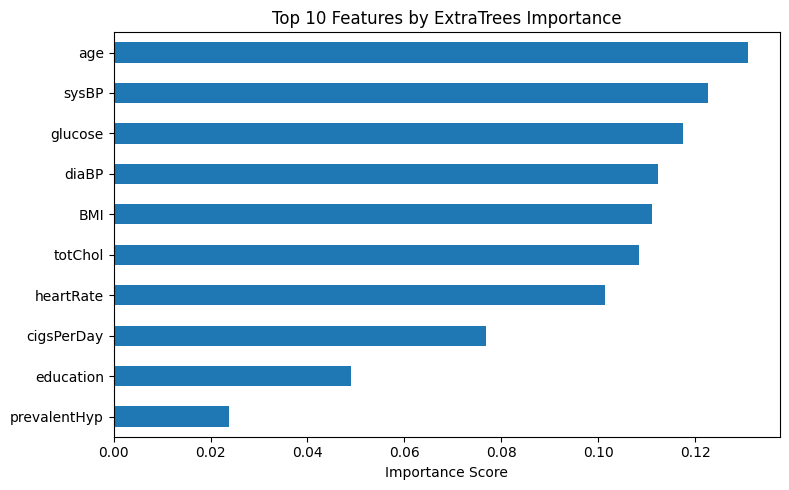

In [44]:
from sklearn.ensemble import ExtraTreesClassifier

X_all = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

etc = ExtraTreesClassifier(random_state=42)
etc.fit(X_all, y)

importance_series = pd.Series(etc.feature_importances_, index=X_all.columns)
importance_series.nlargest(10).sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Top 10 Features by ExtraTrees Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

The continuous medical measurements dominate; `glucose`, `age`, `sysBP`, `totChol` and `heartRate` all rank highly. Among the binary features `prevalentHyp` stands out as the most important categorical predictor, which lines up with what the chi-square test showed.